Import libraries

In [14]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set the path to the file you'd like to load
file_path = "wildfire_events.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "meruvakodandasuraj/global-wildfire-intelligence-20012026",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [6]:
df.shape

(9277, 39)

In [7]:
df.head

<bound method NDFrame.head of        event_id        date  year  month  day_of_year  season region_id  \
0     WF0000001  2001-02-01  2001      2           32  Summer   aus_nsw   
1     WF0000002  2001-02-13  2001      2           44  Summer   aus_nsw   
2     WF0000003  2001-12-18  2001     12          352  Summer   aus_nsw   
3     WF0000004  2001-11-22  2001     11          326  Autumn   aus_nsw   
4     WF0000005  2001-12-01  2001     12          335  Summer   aus_nsw   
...         ...         ...   ...    ...          ...     ...       ...   
9272  WF0009273  2026-12-02  2026     12          336  Summer   nam_osh   
9273  WF0009274  2026-12-02  2026     12          336  Summer   nam_osh   
9274  WF0009275  2026-12-24  2026     12          358  Summer   nam_osh   
9275  WF0009276  2026-12-27  2026     12          361  Summer   nam_osh   
9276  WF0009277  2026-11-13  2026     11          317  Autumn   nam_osh   

          region_name    country continent  ...  relative_humidity_pc

In [8]:
col_names = df.columns
col_names

Index(['event_id', 'date', 'year', 'month', 'day_of_year', 'season',
       'region_id', 'region_name', 'country', 'continent', 'latitude',
       'longitude', 'climate_zone', 'vegetation_type',
       'fire_radiative_power_mw', 'burn_area_hectares', 'burn_area_km2',
       'severity', 'fire_duration_days', 'contained', 'human_caused',
       'detection_satellite', 'detection_confidence', 'co2_emissions_tonnes',
       'pm25_emissions_tonnes', 'pm10_emissions_tonnes', 'co_emissions_tonnes',
       'ch4_emissions_tonnes', 'air_temp_celsius', 'relative_humidity_pct',
       'wind_speed_kmh', 'wind_direction', 'drought_index',
       'structures_threatened', 'structures_destroyed', 'evacuation_orders',
       'people_evacuated', 'enso_phase', 'climate_anomaly_year'],
      dtype='str')

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9277 entries, 0 to 9276
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event_id                 9277 non-null   str    
 1   date                     9277 non-null   str    
 2   year                     9277 non-null   int64  
 3   month                    9277 non-null   int64  
 4   day_of_year              9277 non-null   int64  
 5   season                   9277 non-null   str    
 6   region_id                9277 non-null   str    
 7   region_name              9277 non-null   str    
 8   country                  9277 non-null   str    
 9   continent                9277 non-null   str    
 10  latitude                 9277 non-null   float64
 11  longitude                9277 non-null   float64
 12  climate_zone             9277 non-null   str    
 13  vegetation_type          9277 non-null   str    
 14  fire_radiative_power_mw  9277 non-n

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['climate_zone_encoded'] = label_encoder.fit_transform(df['climate_zone'])
df['human_caused_encoded'] = df['human_caused'].replace(1, "Human caused").replace(0, "Lighning caused")

df['human_caused_encoded']

0          Human caused
1       Lighning caused
2       Lighning caused
3       Lighning caused
4       Lighning caused
             ...       
9272       Human caused
9273       Human caused
9274    Lighning caused
9275    Lighning caused
9276       Human caused
Name: human_caused_encoded, Length: 9277, dtype: object

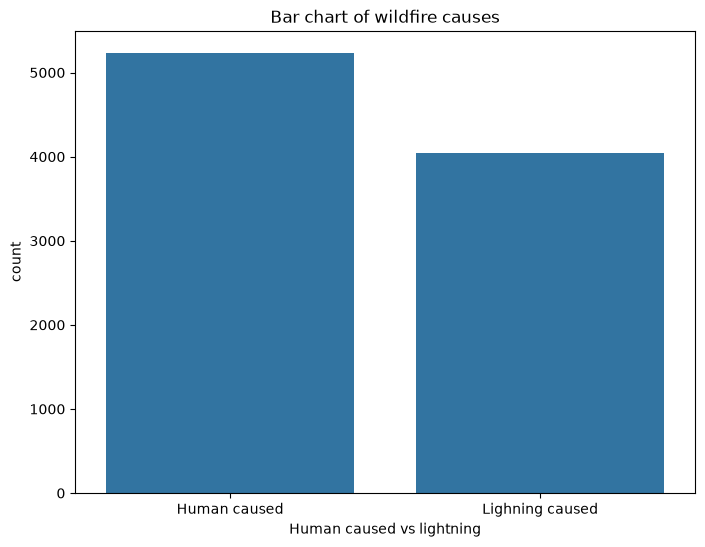

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

with plt.style.context('default'):

    sns.countplot(x="human_caused_encoded", data=df)
    ax.set(xlabel="Human caused vs lightning", ylabel="wildfires", title="Bar chart of wildfire causes")

plt.show()

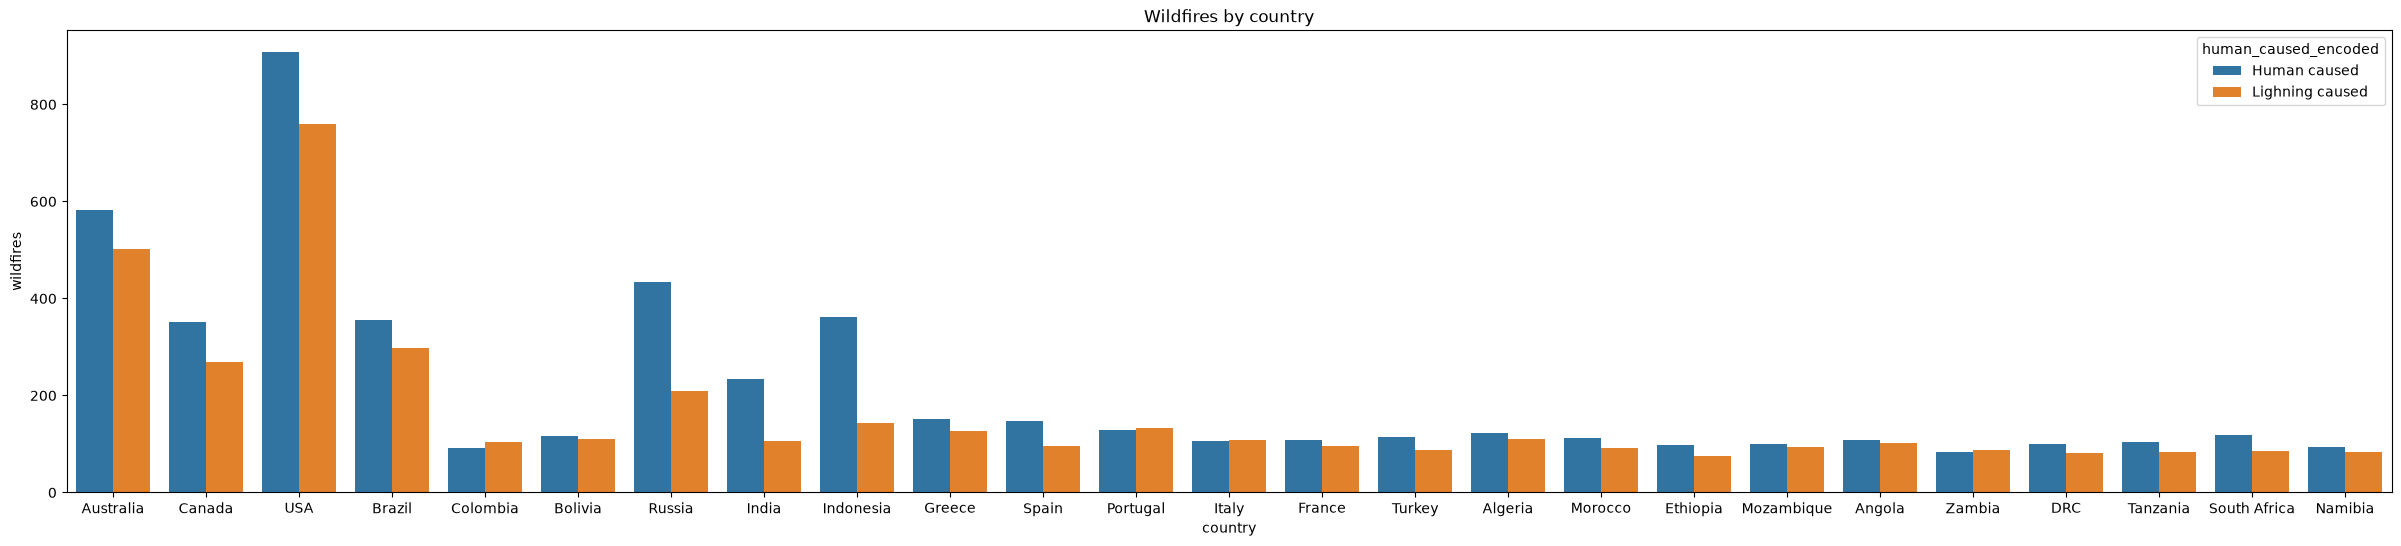

In [91]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(30,6))

    sns.countplot(x=df['country'], hue="human_caused_encoded", data=df)
    ax.set(xlabel="country", ylabel="wildfires", title="Wildfires by country")

plt.show()

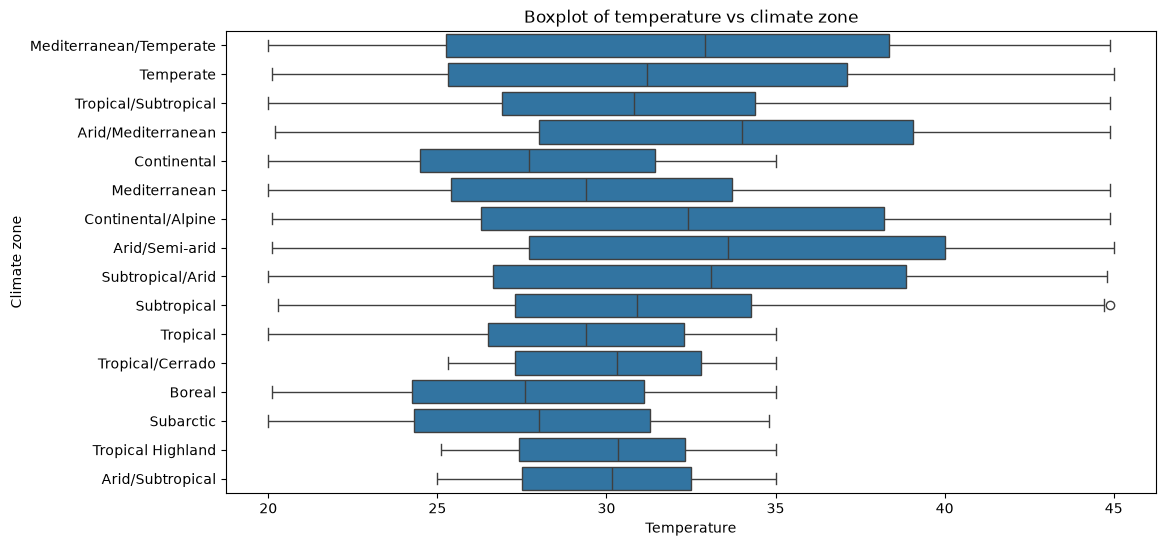

In [39]:
climate_zones = df['climate_zone'].unique()

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12,6))


    sns.boxplot(x="air_temp_celsius", y="climate_zone", data=df, ax=ax)
    ax.set(xlabel="Temperature", ylabel="Climate zone", title="Boxplot of temperature vs climate zone")
plt.show()

In [48]:
fig,ax = plt.subplots(figsize=(8,6))

ax.scatter(x=df['relative_humidity_pct'], y=df['drought_index'])

ax.set(xlabel="Temperature (Celcius)", ylabel="Drought index", title="Scatter plot temp vs drought index")


[Text(0.5, 0, 'Temperature (Celcius)'),
 Text(0, 0.5, 'Drought index'),
 Text(0.5, 1.0, 'Scatter plot temp vs drought index')]

In [81]:
null_count = df.isnull().sum()

# print(null_count)